## RNN Model Building LSTM (Long Short-Term Memory)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import edf

original_df, _, _, _, _ = edf.get_data_for_modeling()

In [15]:
# Prepare the data for LSTM model (Multivariate)
features = original_df.columns.tolist()
target = 'Demand'
feature_cols = [c for c in features if c != target]

data = original_df[feature_cols + [target]].values
training_data_len = int(np.ceil(len(data) * 0.8))

# Preprocessing: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

train_data = scaled_data[0:training_data_len, :]

X_train = []
Y_train = []

# Create a sliding window of 24 hours to predict the next hour's demand
for i in range(24, len(train_data)):
    X_train.append(train_data[i-24:i, :-1]) # All columns except last (target)
    Y_train.append(train_data[i, -1])     # Last column (target)

X_train, Y_train = np.array(X_train), np.array(Y_train)
# X_train shape: (samples, time_steps, features)

In [16]:
# Building the LSTM model
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

# Building the LSTM model
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

early_stop = EarlyStopping(
    monitor='val_loss',        # metric to watch
    patience=10,                # stop after 10 epochs of no improvement
    restore_best_weights=True  # revert to best epoch weights
)

model.summary()
model.compile(optimizer='adam', loss='mae', metrics=[keras.metrics.RootMeanSquaredError()])

history = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_split=0.01, callbacks=[early_stop])


model.summary()
model.compile(optimizer='adam', loss='mae', metrics=[keras.metrics.RootMeanSquaredError()])

history = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_split=0.01, callbacks=[early_stop])

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 24, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,169 (278.00 KB)

 Trainable params: 71,169 (278.00 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 213,509 (834.02 KB)

 Trainable params: 71,169 (278.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,340 (556.02 KB)

Epoch 1/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 43s 33ms/step - loss: 0.1189 - root_mean_squared_error: 0.1521 - val_loss: 0.1205 - val_root_mean_squared_error: 0.1565
Epoch 2/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - loss: 0.1173 - root_mean_squared_error: 0.1501 - val_loss: 0.1155 - val_root_mean_squared_error: 0.1445
Epoch 3/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - loss: 0.1166 - root_mean_squared_error: 0.1491 - val_loss: 0.1209 - val_root_mean_squared_error: 0.1527
Epoch 4/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - loss: 0.1153 - root_mean_squared_error: 0.1476 - val_loss: 0.1045 - val_root_mean_squared_error: 0.1346
Epoch 5/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 38s 35ms/step - loss: 0.1149 - root_mean_squared_error: 0.1472 - val_loss: 0.1055 - val_root_mean_squared_error: 0.1343
Epoch 6/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - loss: 0.1137 - root_mean_squared_error: 0.1455 - val_loss: 0.1147 - val_root_mean_squared_error: 0.1444
Epoch 7/20
1081/1081 ━━━━━━━

In [17]:
# Prepare the test data
test_data = scaled_data[training_data_len - 24:, :]
X_test = []
Y_actual = original_df[target].values[training_data_len:]
Y_actual = Y_actual.reshape(-1, 1)

for i in range(24, len(test_data)):
    X_test.append(test_data[i-24:i, :-1])

X_test = np.array(X_test)

# Make predictions
predictions = model.predict(X_test)

# To inverse transform the prediction, we need to provide the same shape as scaled_data
# We'll create a dummy array for this purpose
dummy = np.zeros((len(predictions), data.shape[1]))
dummy[:, -1] = predictions.flatten()
inverse = scaler.inverse_transform(dummy)
predictions = inverse[:, -1].reshape(-1, 1)

# Evaluating the LSTM model
mae_lstm = mean_absolute_error(Y_actual, predictions)
rmse_lstm = np.sqrt(mean_squared_error(Y_actual, predictions))
r2_lstm = r2_score(Y_actual, predictions)
mape_lstm = np.mean(np.abs((Y_actual - predictions) / Y_actual)) * 100

print('LSTM RMSE:', rmse_lstm)
print('LSTM MAE:', mae_lstm)
print('LSTM R^2 Score (Accuracy):', r2_lstm)
print(f'LSTM MAPE: {mape_lstm:.2f}%')

# Calculate Confidence Interval (95%)
residuals = Y_actual - predictions
std_residuals = np.std(residuals)
confidence_interval = 1.96 * std_residuals
print(f'LSTM 95% Confidence Interval: +/- {confidence_interval:.2f}')

273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
LSTM RMSE: 233.22304983722745
LSTM MAE: 177.88476583975495
LSTM R^2 Score (Accuracy): 0.9727367997809314
LSTM MAPE: 3.92%
LSTM 95% Confidence Interval: +/- 428.87


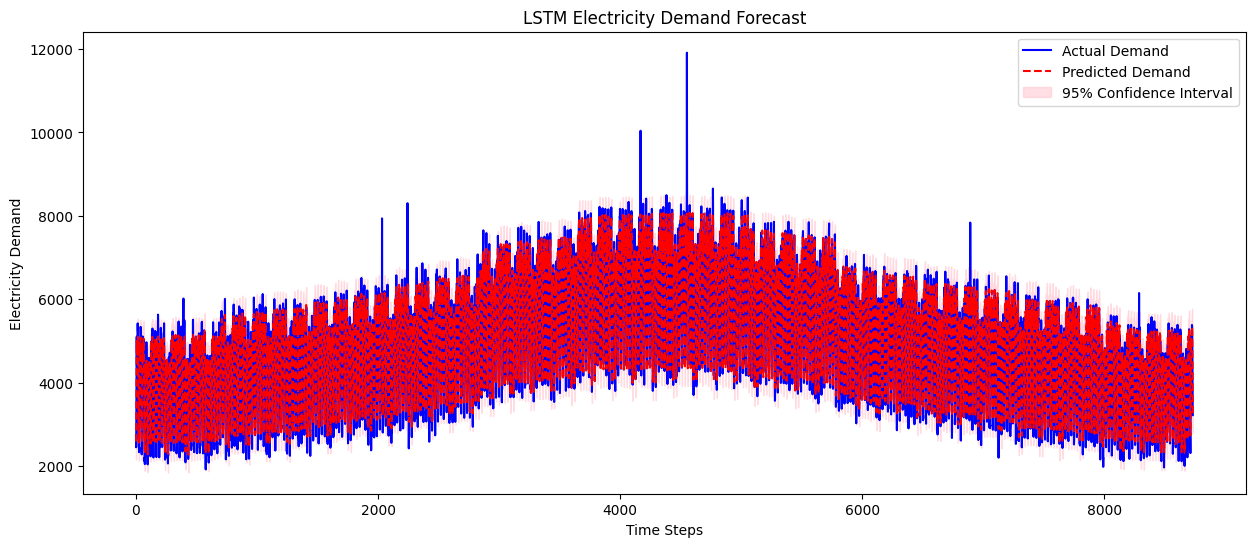

In [18]:
# Visualize the predictions vs actual values
plt.figure(figsize=(15,6))
plt.plot(range(len(Y_actual)), Y_actual, label='Actual Demand', color='blue')
plt.plot(range(len(predictions)), predictions, label='Predicted Demand', color='Red', linestyle='--')
plt.fill_between(range(len(predictions)), 
                 (predictions.flatten() - confidence_interval), 
                 (predictions.flatten() + confidence_interval), 
                 color='pink', alpha=0.5, label='95% Confidence Interval')
plt.title("LSTM Electricity Demand Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()